# Equation for the quantum perturbations (MS) in the Costant potential model

I want to get the explicit formulation of the Mukhanov-Sasaki equation for the Constant potential case in conformal time.
I consider the paper 'The Born-Oppenheimer approach to
Quantum Cosmology' by Alexander Y. Kamenshchik, Alessandro Tronconi and Giovanni Venturi. I will implicitly assume all of their derivations up to the equation for the perturbations (equation 55) $i\partial _{\eta} \tilde{\chi_k} = \mathcal{H_k} \tilde{\chi_k}$, I will also use the same notations.Moreover, I will not write the general derivation from the equation in Schrodinger form (equation 55), to the standard Mukhanov-Sasaki equation:$v_k''+\omega _k v=0$ (it consists on the homogeneous part of the Pinney equation: $ v_k''+\omega _k v_k= \frac{1}{v_k ^3}$ coming from the Invariant method).
The classical dynamics is governed by the Friedmann equation  $H= C\sqrt{\frac{P^2}{2 a^6} + L}$, with $C=\frac{1}{\sqrt{3}M_P}$, $\Lambda$ the Constant potential, and H the Hubble parameter. In conformal time $H=\frac{a''}{a^2}$. 


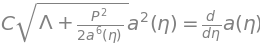

In [1]:
import sympy as sp
#  define the parameters 
C, P, Lambda = sp.symbols('C P Lambda') # C is 1/sqrt(3M_P^2), P is the momentum associated with the scalar field, L is the constant potential

eta = sp.symbols('eta') # conformal time 
a = sp.Function('a')(eta) # scale factor
H = C * sp.sqrt((P**2) / (2 * a**6) + Lambda) #Friedmann equation

deriv_a = a**2 *H #Friedmann equation: deriv_a is the conformal time derivative of a

eq = sp.Eq(deriv_a, sp.diff(a, eta))
sp.init_printing()
display(eq)


## Mukhanov-Sasaki Equation
We directly try to solve the equation for the perturbation: $v_k''+\omega _k v=0$, with $\omega _k =k^2 - \frac{z''}{z}$

We can get explicitly the term z''/z, with $z=a \sqrt{\epsilon_1}$ and $\epsilon_1=-\frac{H'}{aH^2}$

This calculation will lead to have multiple terms with derivatives of the scale factor with respect to the conformal time. We can express those in term of the scale factor itself, through the Friedmann equation

Calculation of H'

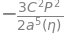

In [2]:
H_prime = sp.diff(H, eta) # derivative of H
deriv_H = H_prime.subs(sp.diff(a, eta), deriv_a) # derivative of H, expressed in term of a itself
sp.init_printing()
display(deriv_H) #display of H'

Calculation of Epsilon

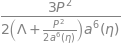

In [3]:
epsilon=-(deriv_H/(H**2 *a)) #definition of epsilon, the first slow-roll parameter
sp.init_printing()
display(epsilon)

Calculation of z

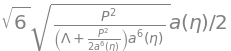

In [4]:
z=a*sp.sqrt(epsilon) #definition of z
sp.init_printing()
display(z)

Calculation of z''

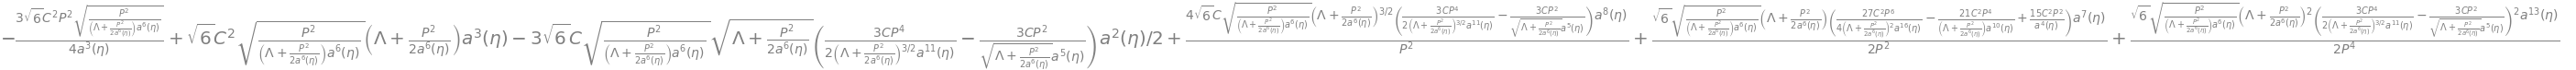

In [5]:
deriv_z = sp.diff(z, eta) # first derivative of z
first_der_z = deriv_z.subs(sp.diff(a, eta), deriv_a) # first derivative of z, expressed in term of a itself
deriv_sec_z = sp.diff(first_der_z, eta) # second derivative of z
second_der_z = deriv_sec_z.subs(sp.diff(a, eta), deriv_a) # second derivative of z, expressed in term of a itself
sp.init_printing()
display(second_der_z)

Calculation of $\frac{z''}{z}$

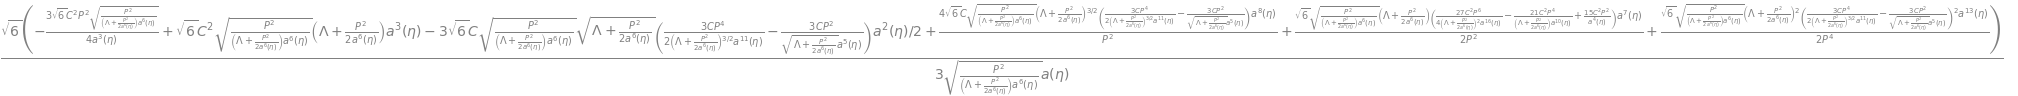

In [6]:
MS=second_der_z/z
sp.init_printing()
display(MS)

Simplifying,
It becomes remarkably easy

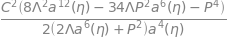

In [7]:
MS_final = sp.simplify(MS)
sp.init_printing()
display(MS_final)

### The Final equation we need to solve is then:
### $v_k '' + \left( k^2 - \frac{\frac{1}{3M_P^2} (8 \Lambda^2 a^{12} (\eta) -34 \Lambda P^2 a^6 (\eta)- P^4)}{2(2\Lambda a^6(\eta) +P^2)a^4 (\eta)} \right)v_k =0$
for very large a, $\frac{z''}{z}$ is proportional to $a^2$.
While in the cosmic time we would have
### $\ddot{v_k} + \left( k^2 - \frac{\frac{1}{3M_P^2} (100 \Lambda^2 a^{12} (\eta) -104 \Lambda P^2 a^6 (\eta)- 5P^4)}{8(2\Lambda a^6(\eta) +P^2)a^6 (\eta)} \right)v_k =0$
Which becomes $\frac{\ddot{z}}{z}\rightarrow \frac{25\Lambda}{12M_P^2}$


In [9]:
sp.init_printing()
display(sp.simplify(MS_final -MS))